# Electrolyser Data Analysis part 2
In this part of the electrolyser data analysis, a closer look is taken to the current-voltage characteristics when the electrolyser is set under unsteady operation modes (following the solar generation pattern)

Current folder: /Users/daan/Library/CloudStorage/SynologyDrive-MacBook/TU Delft/Master SET/Thesis/Data/Data Analysis (Python)


----------------------------------------------------------------------------------------------------
---------------------------- Electrolyser operating at Cloudy condition -----------------------------
----------------------------------------------------------------------------------------------------


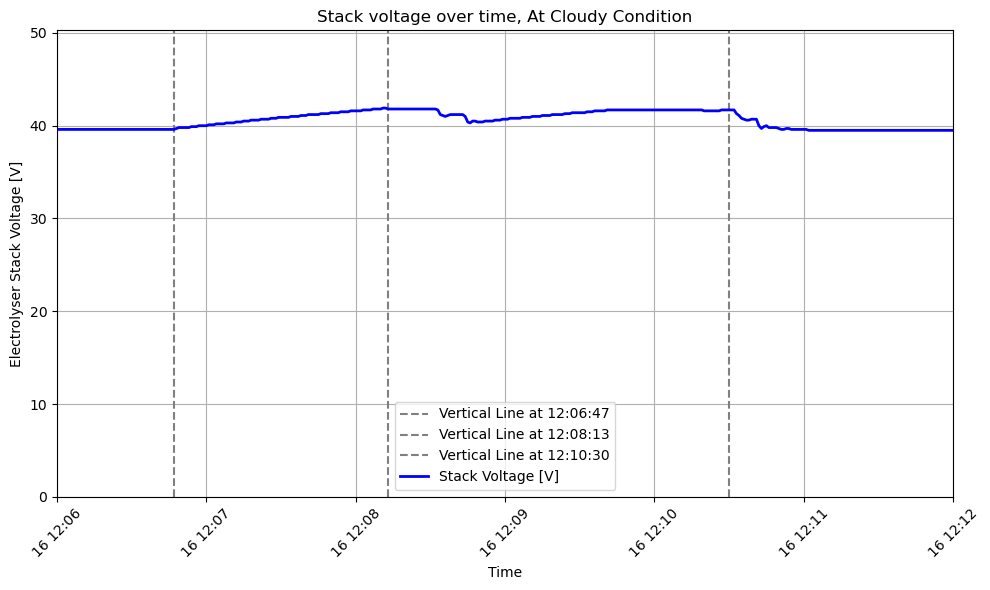

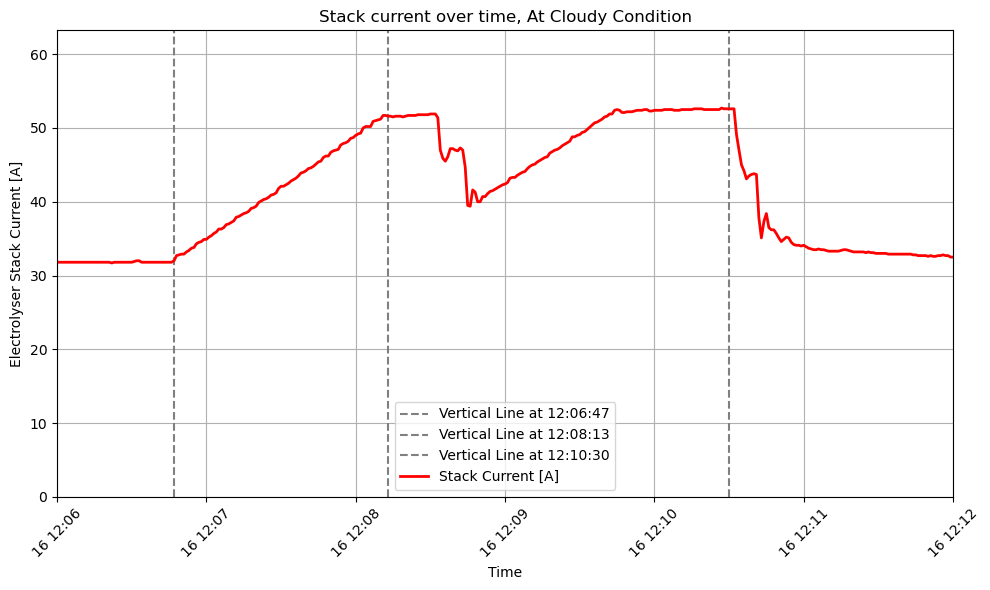

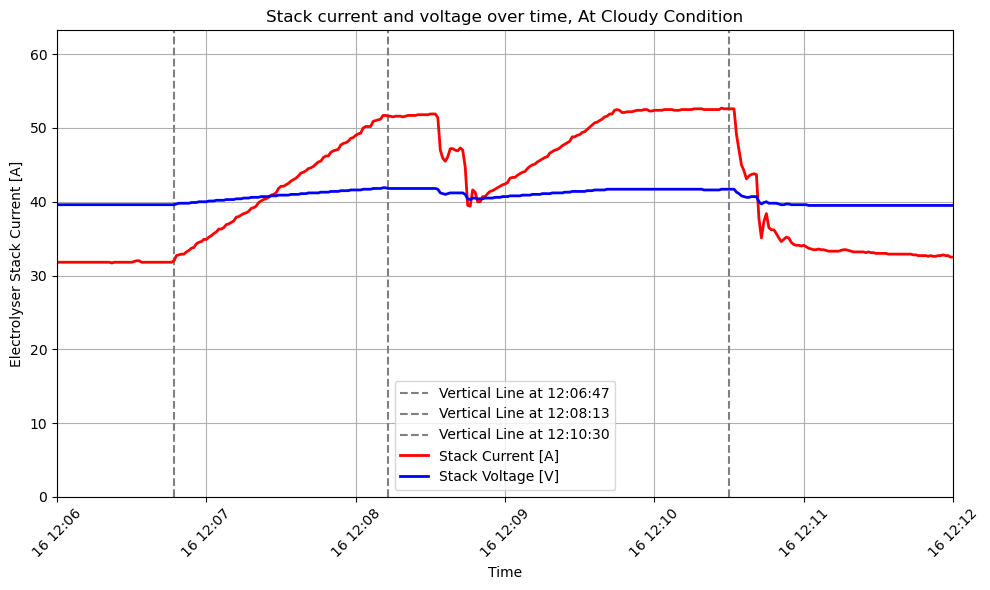

<Figure size 1000x600 with 0 Axes>

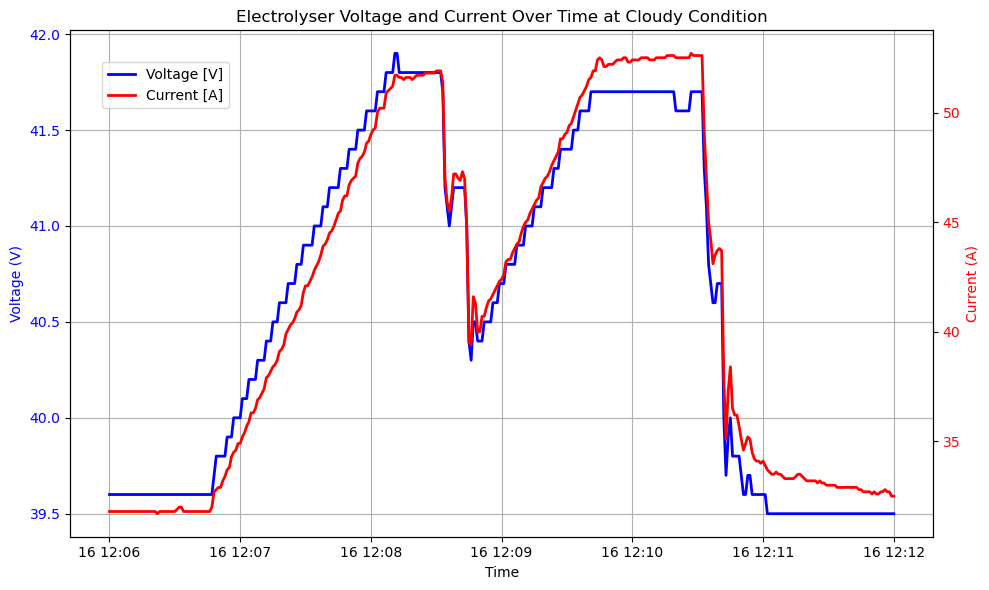

<Figure size 1000x600 with 0 Axes>

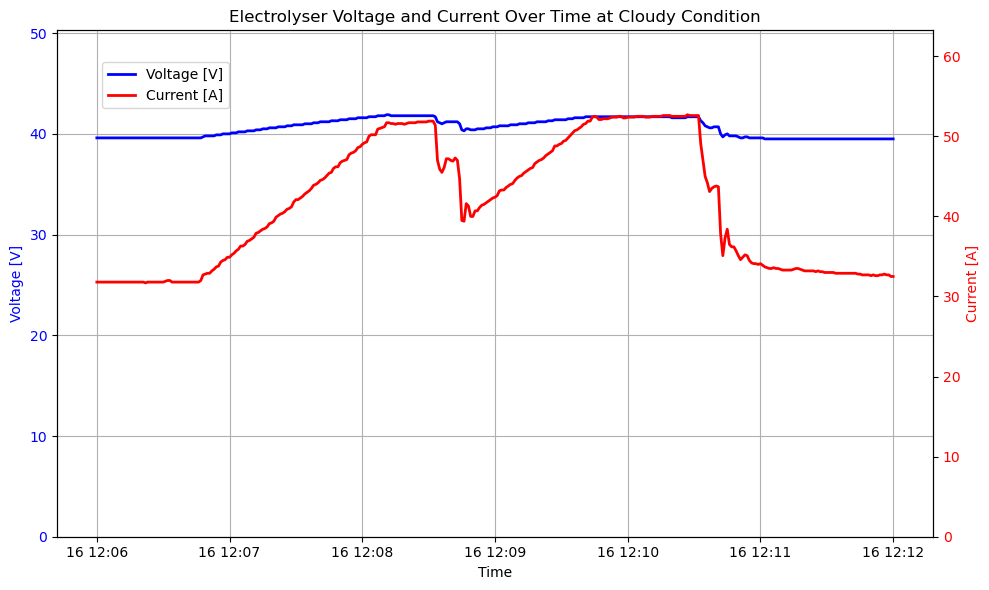

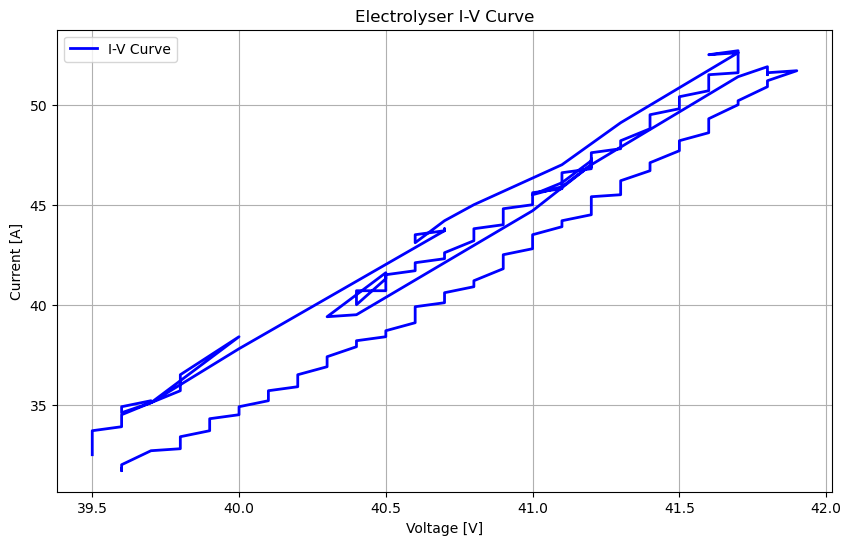

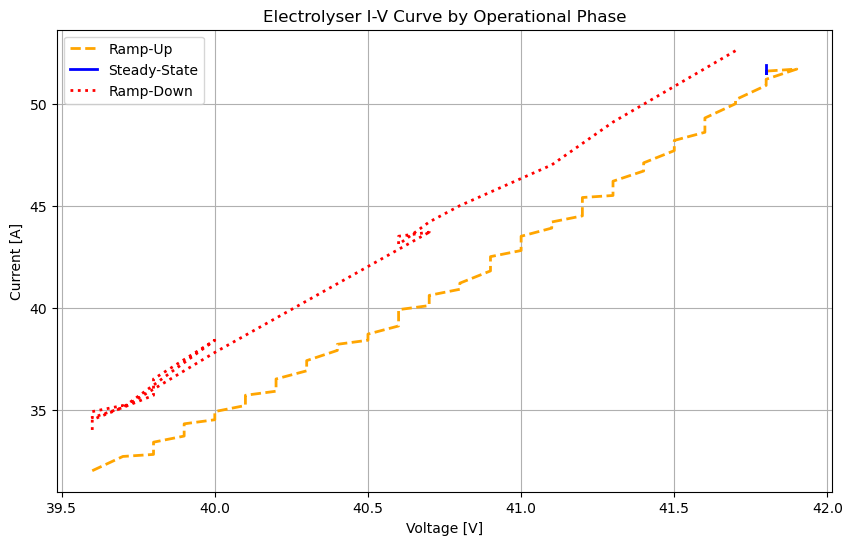

In [4]:
""
"  This Code is created by Daan Schat - 5169801 - TU Delft Master Student SET"
"  for the Green Village energy hub project"
""

# Setting up the environment:
import matplotlib.pyplot as plt
import random
import pandas as pd
import numpy as np
import os
import chardet
from IPython.display import display, Javascript

# Variables & Constants:
LHV_H2 = 120000000 # J/kg
HHV_H2 = 142000000 # J/kg
MolarVolume = 22.414 # L/mol.
MolarMass = 2.016 # g/mol
H2Density = MolarMass/MolarVolume # g/L


files = ["Electrolyser Follow PV Power - Sunny.csv","Electrolyser Follow PV Power - Cloudy.csv"]
print("Current folder:", os.getcwd())


for file in files:
    subfolder = "Joel Electrolyser data"
    file_path = os.path.join(subfolder, file)

    df = pd.read_csv(file_path, sep=',', skiprows=1)
    name = os.path.splitext(os.path.basename(file))[0]  # Remove file extension
    name = name.split(' - ')[-1]  # Split by " - " and take the last part
    


df = df.rename(columns={'Electrolyser Power (W)': 'Total Electrolyser Power (W)'})
columns_to_fill = ['Total Electrolyser Power (W)', 'Electrolyser Production Rate (%)', 'Hydrogen Flow Rate (NL/h)','Electrolyser Stack Voltage (V)','Electrolyser Stack Current (A)',]  # Specify your columns here (e.g., 'A', 'B')
df.loc[:df.first_valid_index(), columns_to_fill] = df.loc[:df.first_valid_index(), columns_to_fill].fillna(0)
df.loc[df.last_valid_index() + 1:, columns_to_fill] = df.loc[df.last_valid_index() + 1:, columns_to_fill].fillna(0)

vlines = ['16-07-2024 12:06:47', '16-07-2024 12:08:13', '16-07-2024 12:10:30'] # Start of electrolyser winding up, Electrolyser full power,
vlines = pd.to_datetime(vlines, dayfirst=True)


df['Hydrogen Flow Rate (NL/h)'] = df['Hydrogen Flow Rate (NL/h)'].interpolate(method='linear')
df['Electrolyser Production Rate (%)'] = df['Electrolyser Production Rate (%)'].interpolate(method='linear')
df['Total Electrolyser Power (W)'] = df['Total Electrolyser Power (W)'].interpolate(method='linear')
df['Electrolyser Stack Voltage (V)'] = df['Electrolyser Stack Voltage (V)'].interpolate(method='linear')
df['Electrolyser Stack Current (A)'] = df['Electrolyser Stack Current (A)'].interpolate(method='linear')
df['Container PV Power (W)'] = df['Container PV Power (W)'].interpolate(method='linear')
df['Electrolyser Power (W)'] = df['Electrolyser Stack Voltage (V)'] * df['Electrolyser Stack Current (A)']


df['Time'] = pd.to_datetime(df['Time'])
start_time = '16-07-2024 12:06:00'  # replace with your start time
end_time = '16-07-2024 12:12:00'    # replace with your end time
df = df[(df['Time'] >= start_time) & (df['Time'] <= end_time)]
    
Time = pd.to_datetime(df['Time'])
time_numeric = (Time - Time.iloc[0]).dt.total_seconds().astype(int)

    
print()
print()
print('----------------------------------------------------------------------------------------------------')
print(f'---------------------------- Electrolyser operating at {name} condition -----------------------------')
print('----------------------------------------------------------------------------------------------------')

    
# Stack voltage over Time
values = df['Electrolyser Stack Voltage (V)']


plt.figure(figsize=(10, 6))
for vline in vlines:
    plt.axvline(x=vline, color='gray', linestyle='--', label=f'Vertical Line at {vline.strftime("%H:%M:%S")}')
    
plt.plot(df['Time'], df['Electrolyser Stack Voltage (V)'], label='Stack Voltage [V]', color='b', linewidth = 2)
plt.title(f'Stack voltage over time, At {name} Condition')
plt.xlabel('Time')
plt.ylabel('Electrolyser Stack Voltage [V]')
plt.xlim(df['Time'].min(), df['Time'].max())
plt.ylim(0, df['Electrolyser Stack Voltage (V)'].max()*1.2)
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.savefig(f"figures/Electrolyser report/Electrolyser Stack Voltage - CloseLook - {name}.png")
plt.show()

  
# Stack current over Time
values = df['Electrolyser Stack Current (A)']

plt.figure(figsize=(10, 6))
for vline in vlines:
    plt.axvline(x=vline, color='gray', linestyle='--', label=f'Vertical Line at {vline.strftime("%H:%M:%S")}')
    
plt.plot(df['Time'], df['Electrolyser Stack Current (A)'], label='Stack Current [A]', color='r', linewidth = 2)
plt.title(f'Stack current over time, At {name} Condition')
plt.xlabel('Time')
plt.ylabel('Electrolyser Stack Current [A]')
plt.xlim(df['Time'].min(), df['Time'].max())
plt.ylim(0, df['Electrolyser Stack Current (A)'].max()*1.2)
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.savefig(f"figures/Electrolyser report/Electrolyser Stack Current - CloseLook - {name} - 1.png")
plt.show()


# Stack voltage over Time
values = df['Electrolyser Stack Current (A)']

plt.figure(figsize=(10, 6))
for vline in vlines:
    plt.axvline(x=vline, color='gray', linestyle='--', label=f'Vertical Line at {vline.strftime("%H:%M:%S")}')
    
plt.plot(df['Time'], df['Electrolyser Stack Current (A)'], label='Stack Current [A]', color='r', linewidth = 2)
plt.plot(df['Time'], df['Electrolyser Stack Voltage (V)'], label='Stack Voltage [V]', color='b', linewidth = 2)

plt.title(f'Stack current and voltage over time, At {name} Condition')
plt.xlabel('Time')
plt.ylabel('Electrolyser Stack Current [A]')
plt.xlim(df['Time'].min(), df['Time'].max())
plt.ylim(0, df['Electrolyser Stack Current (A)'].max()*1.2)
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.savefig(f"figures/Electrolyser report/Electrolyser Stack Current - CloseLook - {name} - 2.png")
plt.show()


# From min to max current and voltage
plt.figure(figsize=(10, 6))

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(df['Time'], df['Electrolyser Stack Voltage (V)'], color='b', label='Voltage [V]', linewidth = 2)
ax1.set_xlabel('Time')
ax1.set_ylabel('Voltage (V)', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.grid(True)

ax2 = ax1.twinx()  # Create a second y-axis sharing the same x-axis
ax2.plot(df['Time'], df['Electrolyser Stack Current (A)'], color='r', label='Current [A]', linewidth = 2)
ax2.set_ylabel('Current (A)', color='r')
ax2.tick_params(axis='y', labelcolor='r')

# Title and legend
plt.title(f'Electrolyser Voltage and Current Over Time at {name} Condition')
fig.tight_layout()  # Adjust layout to prevent overlap
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))  # Add legend outside of the plot area
plt.savefig(f"figures/Electrolyser report/Electrolyser Voltage and Current - {name} - 1.png")
plt.show()


# From 0 to max current and voltage
plt.figure(figsize=(10, 6))

# Plot the first y-axis (Voltage)
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(df['Time'], df['Electrolyser Stack Voltage (V)'], color='b', label='Voltage [V]', linewidth = 2)
ax1.set_xlabel('Time')
ax1.set_ylabel('Voltage [V]', color='b')
ax1.set_ylim(0, df['Electrolyser Stack Voltage (V)'].max() * 1.2)  # Y-axis starts from 0
ax1.tick_params(axis='y', labelcolor='b')
ax1.grid(True)

# Add the second y-axis (Current)
ax2 = ax1.twinx()  # Create a second y-axis sharing the same x-axis
ax2.plot(df['Time'], df['Electrolyser Stack Current (A)'], color='r', label='Current [A]', linewidth = 2)
ax2.set_ylabel('Current [A]', color='r')
ax2.set_ylim(0, df['Electrolyser Stack Current (A)'].max() * 1.2)  # Y-axis starts from 0
ax2.tick_params(axis='y', labelcolor='r')

# Title and legend
plt.title(f'Electrolyser Voltage and Current Over Time at {name} Condition')
fig.tight_layout()  # Adjust layout to prevent overlap
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))  # Add legend outside of the plot area

# Save and show the plot
plt.savefig(f"figures/Electrolyser report/Electrolyser Voltage and Current - {name} - 2.png")
plt.show()



# IV Curve:
plt.figure(figsize=(10, 6))
plt.plot(df['Electrolyser Stack Voltage (V)'], df['Electrolyser Stack Current (A)'], linewidth = 2, linestyle='-', color='b', label='I-V Curve')

plt.xlabel('Voltage [V]')
plt.ylabel('Current [A]')
plt.title('Electrolyser I-V Curve')
plt.grid(True)
plt.legend()
plt.savefig(f"figures/Electrolyser report/Electrolyser IV Curve - {name}.png")
plt.show()




#Seperate IV curves:
ramp_up_start = pd.to_datetime('16-07-2024 12:06:47', dayfirst=True)
ramp_up_end = pd.to_datetime('16-07-2024 12:08:13', dayfirst=True)

steady_state_start = pd.to_datetime('16-07-2024 12:08:13', dayfirst=True)
steady_state_end = pd.to_datetime('16-07-2024 12:08:30', dayfirst=True)

ramp_down_start = pd.to_datetime('16-07-2024 12:10:30', dayfirst=True)
ramp_down_end = pd.to_datetime('16-07-2024 12:11:00', dayfirst=True)

ramp_up = df[(df['Time'] >= ramp_up_start) & (df['Time'] <= ramp_up_end)]
ramp_down = df[(df['Time'] >= ramp_down_start) & (df['Time'] <= ramp_down_end)]

steady_state = df[(df['Time'] >= steady_state_start) & (df['Time'] <= steady_state_end)]


plt.figure(figsize=(10, 6))

plt.plot(ramp_up['Electrolyser Stack Voltage (V)'], ramp_up['Electrolyser Stack Current (A)'], 
         linestyle='--', color='orange', label='Ramp-Up', linewidth = 2)

plt.plot(steady_state['Electrolyser Stack Voltage (V)'], steady_state['Electrolyser Stack Current (A)'], 
         linestyle='-', color='blue', label='Steady-State', linewidth = 2)

plt.plot(ramp_down['Electrolyser Stack Voltage (V)'], ramp_down['Electrolyser Stack Current (A)'], 
         linestyle=':', color='red', label='Ramp-Down', linewidth = 2)

plt.xlabel('Voltage [V]')
plt.ylabel('Current [A]')
plt.title('Electrolyser I-V Curve by Operational Phase')
plt.grid(True)
plt.legend()

# Save and show the plot
plt.savefig(f"figures/Electrolyser report/Electrolyser IV Curve by Phase - {name}.png")
plt.show()

In [4]:
print(f"maximum voltage: {max(df['Electrolyser Stack Voltage (V)'])}" )
print(f"minimum voltage: {min(df['Electrolyser Stack Voltage (V)'])}" )
print()
print(f"maximum current: {max(df['Electrolyser Stack Current (A)'])}" )
print(f"minimum current: {min(df['Electrolyser Stack Current (A)'])}" )

maximum voltage: 41.9
minimum voltage: 39.5

maximum current: 52.7
minimum current: 31.7


                     Time  Total Electrolyser Power (W)  \
11997 2024-07-16 12:06:00                        1407.0   
11998 2024-07-16 12:06:01                        1407.0   
11999 2024-07-16 12:06:02                        1407.0   
12000 2024-07-16 12:06:03                        1407.0   
12001 2024-07-16 12:06:04                        1407.0   
...                   ...                           ...   
12353 2024-07-16 12:11:56                        1438.0   
12354 2024-07-16 12:11:57                        1443.0   
12355 2024-07-16 12:11:58                        1443.0   
12356 2024-07-16 12:11:59                        1443.0   
12357 2024-07-16 12:12:00                        1443.0   

       Electrolyser Production Rate (%)  Hydrogen Flow Rate (NL/h)  \
11997                              60.0                      306.0   
11998                              60.0                      306.0   
11999                              60.0                      306.0   
12000      